#**Detecting Fake Reviews**

We will revisit this problem, seeing how sequence models can perform (perhaps they fare better than the simple unigram or bigram dense networks. Recall that this dataset is the product of research by a few folks in Computer Science: https://aclanthology.org/N13-1053.pdf. Again, we are going to use this fairly recent dataset on fake vs. truthful reviews: https://huggingface.co/datasets/theArijitDas/Fake-Reviews-Dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
from google.colab import files
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pandas as pd
import io

uploaded = files.upload()
reviews = pd.read_csv(io.BytesIO(uploaded['fake reviews dataset.csv']))

reviews.describe(include='all')

Saving fake reviews dataset.csv to fake reviews dataset.csv


,category,rating,label,text_
count,40432,40432.000000,40432,40432
unique,10,NaN,2,40412
top,Kindle_Store_5,NaN,CG,My dog loves these and it has kept her occupie...
freq,4730,NaN,20216,2
mean,NaN,4.256579,NaN,NaN
std,NaN,1.144354,NaN,NaN
min,NaN,1.000000,NaN,NaN
25%,NaN,4.000000,NaN,NaN
50%,NaN,5.000000,NaN,NaN
75%,NaN,5.000000,NaN,NaN


Pull out our labels and review text... CG means computer-generated, i.e., Fake.

In [3]:
labels = np.where(reviews['label']=='CG',1,0)
reviews = np.array(reviews['text_'])

Let's make a TextVectorization() layer to preprocess our text. Note, by default, this will make words lowercase, remove punctuation, and split on white space.

In [4]:
text_vectorization = keras.layers.TextVectorization(
    max_tokens=10000, # We will use the 10000 most frequent terms.
    output_mode="int", # This is requesting integer encodings (which means we'll have a sequence of integers)
    #ragged=True, # This returns a ragged list (sequences of variable length); absent this, the vectorizer will pad.
)

text_vectorization.adapt(reviews)

Just to see what this layer is doing to our reviews...

In [5]:
review_text = reviews[50]
print(f'REVIEW TEXT: \n\n{review_text}')
review_len = len(review_text.split(' '))
print(f'\nREVIEW DETAILS: \n\nThe review contains roughly {review_len} words (based on white spaces).')
vectorized_reviews = text_vectorization(reviews)
print(f'It\'s vectorized (and padded) form contains {vectorized_reviews.shape[1]} tokens.\n') #Including the start index.
print(f'VECTOR REPRESENTATION:\n')
vectorized_reviews[50] # This text vectorization layer will convert a raw text vector into a sequence of integers.

REVIEW TEXT: 

Perfect. They do exactly what I need them to do. I will keep them for a long time

REVIEW DETAILS: 

The review contains roughly 18 words (based on white spaces).
It's vectorized (and padded) form contains 373 tokens.

VECTOR REPRESENTATION:



<tf.Tensor: shape=(373,), dtype=int64, numpy=
array([121,  30, 105, 478,  81,   4, 196,  44,   7, 105,   4,  35, 132,
        44,  11,   3, 126,  78,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,  

#*Model Using a 1D Convolution*

We will pass the integer sequences through a 16-dimensional Embedding layer once it enters our network.

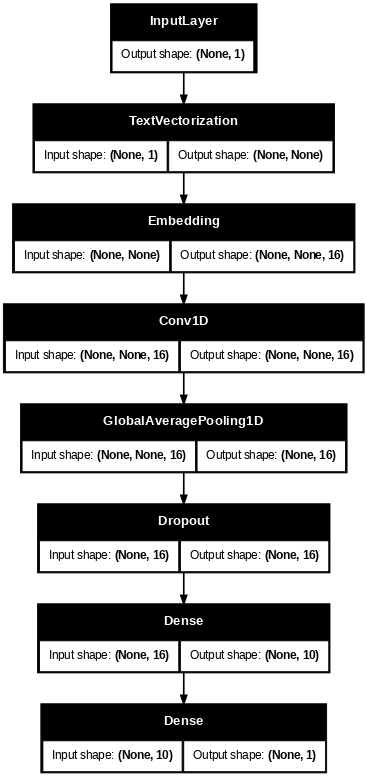

In [6]:
from tensorflow.keras import layers

inputs = keras.layers.Input(shape=(1,), dtype="string")
x = text_vectorization(inputs)
x = layers.Embedding(input_dim=10000, output_dim=16, mask_zero=False)(x)
x = layers.Conv1D(16, 5, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(10, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

keras.utils.plot_model(model, show_shapes=True, dpi=60)

Model size? Most of the weights are from our embedding layer! We map 10,000 unique tokens to 16-dimensional embeddings.

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 16)       │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, None, 16)       │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,477 (630.77 KB)

 Trainable params: 161,477 (630.77 KB)

 Non-trainable params: 0 (0.00 B)

We can now fit our 1D CNN on the reviews (sequences of token-embeddings) to predict Truthful vs. Deceptive review.

In [8]:
history = model.fit(reviews,labels,validation_split=0.2,epochs=5,batch_size=32)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - accuracy: 0.6293 - loss: 0.6244 - val_accuracy: 0.8129 - val_loss: 0.7024
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8352 - loss: 0.3864 - val_accuracy: 0.8610 - val_loss: 0.8295
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8729 - loss: 0.3267 - val_accuracy: 0.8810 - val_loss: 0.7995
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8939 - loss: 0.2687 - val_accuracy: 0.8848 - val_loss: 0.8184
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9045 - loss: 0.2410 - val_accuracy: 0.8887 - val_loss: 0.8323


Let's plot the performance in training and validation... we approach 90% accuracy pretty quickly!

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['accuracy'],c='r')
plt.plot(history.history['val_accuracy'], c='b')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

#*Model Using Bidirectional LSTM with Embeddings*

We will pass our integer sequences into an embedding layer again, and from there into our Bidirectional LSTM. Note that LSTM's accept 'masking' tensors. This means we can tell the LSTM to ignore 0 tokens, which are padding, as it processes sequences of input. This speeds up training and inference quite a lot.

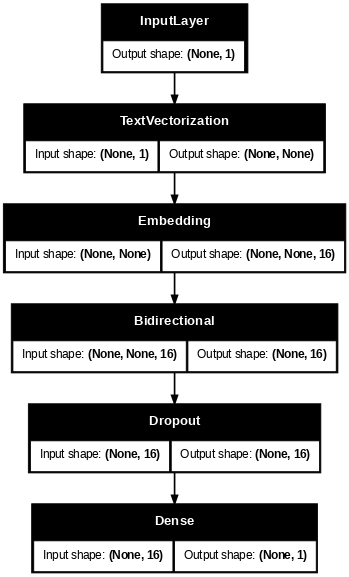

In [10]:
inputs = keras.layers.Input(shape=(1,), dtype="string") # We take our strings as input
processing = text_vectorization(inputs)
embeddings = layers.Embedding(input_dim=10000,output_dim=16)(processing)
x = layers.Bidirectional(layers.LSTM(8))(embeddings) # Pass the output of the embeddings layer to the LSTM
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs,outputs)

model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

keras.utils.plot_model(model, show_shapes=True, dpi=60)

Now we will fit our model with cross-validation again, as before...

In [11]:
history = model.fit(reviews,labels,validation_split=0.2,epochs=5,batch_size=32)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.8573 - loss: 0.3621 - val_accuracy: 0.8829 - val_loss: 0.2808
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9325 - loss: 0.1985 - val_accuracy: 0.8961 - val_loss: 0.2565
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9419 - loss: 0.1726 - val_accuracy: 0.8855 - val_loss: 0.2810
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9480 - loss: 0.1494 - val_accuracy: 0.9064 - val_loss: 0.2457
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9522 - loss: 0.1382 - val_accuracy: 0.9086 - val_loss: 0.2556


Finally, plot loss / accuracy over training... wow, this model peaks at about the 3rd epoch! It learns much faster than our old model did, though it gets to about the same level of performance.



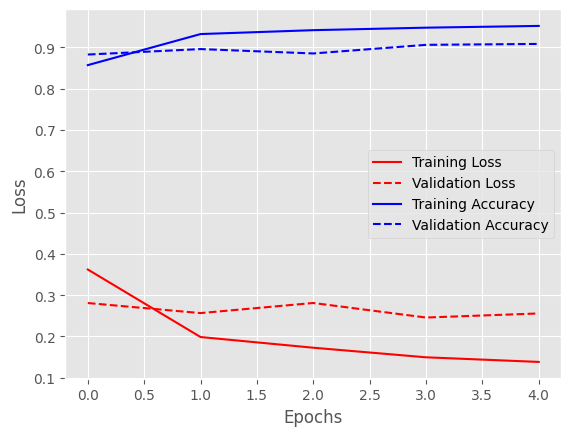

In [12]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c='r')
plt.plot(history.history['val_loss'],c="r",linestyle="dashed")
plt.plot(history.history['accuracy'],c='b')
plt.plot(history.history['val_accuracy'],c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation Loss','Training Accuracy','Validation Accuracy'])
plt.show()

#*Word2Vec Embeddings*

Now we will try out the word2vec pre-trained embeddings (from Wikipedia). Let's download the English language, Wikipedia 100-dimensional embeddings. Note that this can take some time because the embedding file is large and you have to first download it and then unzip it on the Colab server.

In [13]:
!wget http://wikipedia2vec.s3.amazonaws.com/models/en/2018-04-20/enwiki_20180420_100d.pkl.bz2
!bzip2 -d enwiki_20180420_100d.pkl.bz2

--2026-03-16 19:47:40--  http://wikipedia2vec.s3.amazonaws.com/models/en/2018-04-20/enwiki_20180420_100d.pkl.bz2
Resolving wikipedia2vec.s3.amazonaws.com (wikipedia2vec.s3.amazonaws.com)... 52.219.150.33, 3.5.157.134, 52.219.0.193, ...
Connecting to wikipedia2vec.s3.amazonaws.com (wikipedia2vec.s3.amazonaws.com)|52.219.150.33|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3514838671 (3.3G) [application/x-bzip2]
Saving to: ‘enwiki_20180420_100d.pkl.bz2’

enwiki_20180420_100 100%[===================>]   3.27G  46.6MB/s    in 87s     

2026-03-16 19:49:07 (38.6 MB/s) - ‘enwiki_20180420_100d.pkl.bz2’ saved [3514838671/3514838671]



Now let's create an embedding matrix, as before, etc. Note, we can see that most of the words for which we lack embeddings are actually typos or proper nouns. We could manually fix the typos, or not (perhaps the typos are indicative of deceit!).

In [14]:
try:
  from wikipedia2vec import Wikipedia2Vec
except ImportError as error:
  !pip install wikipedia2vec
  from wikipedia2vec import Wikipedia2Vec

from wikipedia2vec import Wikipedia2Vec

# These embeddings are 100 dimensional vector representations.
embedding_dim = 100

wiki2vec = Wikipedia2Vec.load('enwiki_20180420_100d.pkl')

vocabulary = text_vectorization.get_vocabulary() # From the vocabulary our text vectorizer learned from our dataset, go over every word.
word_index = dict(zip(vocabulary, range(len(vocabulary)))) # Make a dictionary, key is word to value is index.
embedding_matrix = np.zeros((len(vocabulary), embedding_dim))

for word, index in word_index.items():
    try:
        embedding_matrix[index] = wiki2vec.get_word_vector(f'{word}')
    except:
        print(f'Skipping {word}, no embedding for it.')
        continue

print(f'The embedding for \'room\' is {embedding_matrix[15]}.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.2/301.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.5/256.5 kB 29.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/joblib/numpy_pickle.py:255: UserWarning: The memmapped array [[-0.12560804 -0.5235532  -0.13231167 ... -0.48633438  0.45111445
   0.11309847]
 [-0.12473089 -0.6455471   0.13622157 ... -0.6347396   0.5410465
   0.32159257]
 [-0.05129661 -0.4987064  -0.09563554 ... -0.30148467  0.24280211
  -0.08308805]
 ...
 [-1.0583687  -0.83086014 -0.4427682  ... -1.0160557  -0.02469787
   0.99688977]
 [-1.0772408  -0.32139003 -0.79673034 ... -1.3150353  -0.12155519
   0.57841384]
 [-0.86319923 -0.5425662  -0.5506818  ... -1.1069874   0.26995388
   0.43403685]] loaded from the file enwiki_20180420_100d.pkl is not byte aligned. This may cause segmentation faults if this memmapped array is used in some libraries like BLAS or PyTorch. To get rid of this warning, regenerate your pickle file with joblib >= 1.2.0. See https://github.com/joblib/joblib/issues/563 for more details
  warnings.warn(message)
/usr/local/lib/python3.12/dist-packages/joblib/numpy_pickle.py:255

Skipping , no embedding for it.
Skipping [UNK], no embedding for it.
Skipping datahookproductlinklinked, no embedding for it.
Skipping classalinknormal, no embedding for it.
Skipping itthis, no embedding for it.
Skipping anyonei, no embedding for it.
Skipping typehidden, no embedding for it.
Skipping reviewi, no embedding for it.
Skipping wellwritten, no embedding for it.
Skipping producti, no embedding for it.
Skipping itvery, no embedding for it.
Skipping hasnt, no embedding for it.
Skipping againi, no embedding for it.
Skipping seriesi, no embedding for it.
Skipping nicei, no embedding for it.
Skipping youve, no embedding for it.
Skipping authori, no embedding for it.
Skipping werent, no embedding for it.
Skipping purchasethis, no embedding for it.
Skipping reviewthis, no embedding for it.
Skipping welldeveloped, no embedding for it.
Skipping bookthis, no embedding for it.
Skipping pleasedi, no embedding for it.
Skipping moviei, no embedding for it.
Skipping itgreat, no embedding fo

And, again, let's make our embedding layer...

In [15]:
embedding_layer = layers.Embedding(
    len(vocabulary), # 10000 words.
    100, # Vectors of 100 elements per word.
    embeddings_initializer=keras.initializers.Constant(embedding_matrix), # Initialize with fixed values from our matrix.
    trainable=False, # These are weights, but they will be frozen so they don't update during training.
)

And we instantiate the model again...

In [16]:
inputs = keras.layers.Input(shape=(1,), dtype="string") # We take our strings as input
processing = text_vectorization(inputs)

embedding = embedding_layer(processing)

x = keras.layers.Bidirectional(keras.layers.LSTM(8))(embedding)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs,outputs)
model.compile(optimizer="rmsprop",loss="binary_crossentropy",metrics=['accuracy'])

And, let's fit the model one last time and see how we do now? We actually do worse! The custom embeddings we were coming up with on our own were more effective than the general purpose Word2Vec embeddings from Wikipedia. Another issue here could be that lots of tokens in our sample are not being assigned to an embedding because the word didn't exist in the wikipedia sample.

In [17]:
history = model.fit(reviews, labels, validation_split=0.2, epochs=5, batch_size=32)

Epoch 1/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7144 - loss: 0.5551 - val_accuracy: 0.7105 - val_loss: 0.5684
Epoch 2/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8188 - loss: 0.4195 - val_accuracy: 0.7977 - val_loss: 0.4176
Epoch 3/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8484 - loss: 0.3631 - val_accuracy: 0.8175 - val_loss: 0.3850
Epoch 4/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8624 - loss: 0.3300 - val_accuracy: 0.8418 - val_loss: 0.3409
Epoch 5/5
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8716 - loss: 0.3065 - val_accuracy: 0.8462 - val_loss: 0.3379


Plotting average model loss / accuracy across folds, over training.

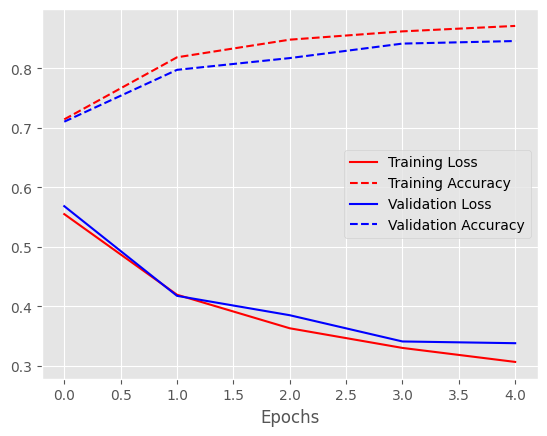

In [18]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

plt.plot(history.history['loss'],c='r')
plt.plot(history.history['accuracy'],c="r",linestyle="dashed")
plt.plot(history.history['val_loss'],c='b')
plt.plot(history.history['val_accuracy'],c='b',linestyle="dashed")
plt.xlabel("Epochs")
plt.legend(['Training Loss','Training Accuracy','Validation Loss','Validation Accuracy'])
plt.show()